# Machine Forgetters CS5841 Final Project Code File
## Utilizing Modern DL Techniques in Mass Spectrometry Bacterial Classifiers
Connor Donahue, Connor Fleser, Jessica Feliz Garrido, and Matthew Harrelson

## **Imports**: import packages used in the notebook

In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import random
import gc
from sklearn.model_selection import KFold
import seaborn as sns
import ast
import keras_hub

## **Load Data**: load data used to construct model
- Our MALDI-TOF data was taken from two separate CSV files and combined into one dataset. One CSV file contained only pure spectra, and the other contained mixed and pure spectra. The pure spectra from the latter CSV were filtered out and added to the other pure spectra for a total of 651 samples.

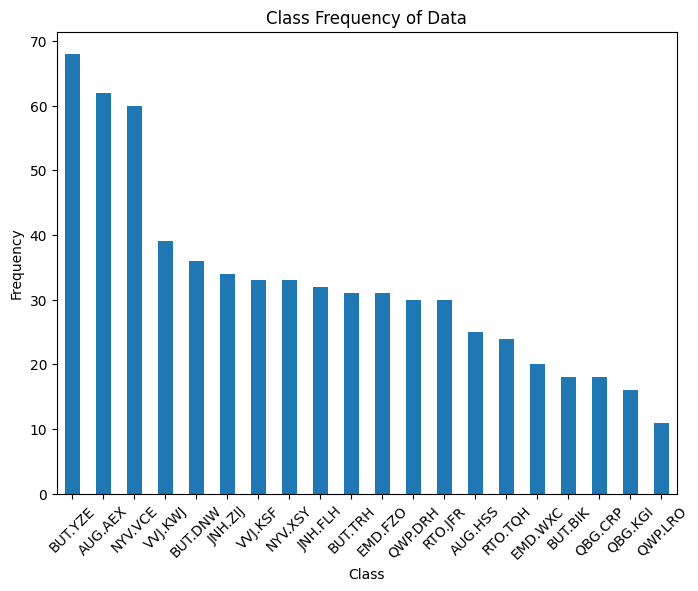

In [ ]:
# read in feature data from two csv files
df1 = pd.read_csv("data/pure_spectra_matrix.csv", sep=";", header = None, decimal =".")
df2 = pd.read_csv("data/mixed_spectra_matrix.csv", sep=";", header = None, decimal =".")

# read in label data from label files
labels1 = pd.read_csv("data/pure_spectra_metadata.csv", sep=";")["Species"]

# for second pair of feature and label file, pure spectra must be separated from mixed spectra
temp_labels2 =  pd.read_csv("data/mixed_spectra_metadata.csv", sep=";")
labels2 = temp_labels2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]
df2 = df2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]

# store labels for pure spectra
species = []
for i in range(labels2.shape[0]):
    if (labels2['Proportion'].iloc[i] == 0):
        species.append(labels2["Species_2"].iloc[i])
    else:
        species.append(labels2["Species_1"].iloc[i])

labels2 = pd.Series(species)

# combine two data sets into one dataframe
df = pd.concat([df1, df2])
labels = pd.concat([labels1, labels2])

# visualize first few entries in the dataframe
df.head()

# plot frequencies of classes
counts = pd.DataFrame(labels).value_counts()
counts.index = [str(i[0]) for i in counts.index]
plt.figure(figsize=(8, 6))
counts.plot(kind='bar')
plt.ylabel('Frequency')
plt.xlabel('Class')
plt.title('Class Frequency of Data')
plt.xticks(rotation=45)
plt.savefig("figures/class_frequency.jpeg", dpi=300, bbox_inches="tight")
plt.show() # Added () to show the plot

## **Preprocessing and Splitting Data**

### Global Variables and Random Seeds

In [ ]:
# set fixed batch size, number of epochs, and random seed
BATCH = 32
EPOCHS = 50
SEED = 42
HE = tf.keras.initializers.HeNormal(seed=SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Training and Testing Spit
- A 10%/90% test/training + validation split, stratified on the outcome classes, was conducted and outcome labels were encoded with one-hot encoding.

In [ ]:
# training and testing split (10% test, 90% training + validation)
X_trainval, X_test, y_trainval, y_test = train_test_split(df, labels, test_size = 0.1, stratify=labels)

# Initialize the encoder
ohe = OneHotEncoder(sparse_output=False)

# Fit and transform
y_trainval = ohe.fit_transform(pd.DataFrame(y_trainval))
y_test = ohe.transform(pd.DataFrame(y_test))

# identify number of outcome classes
num_classes = len(labels.unique())

# display dimensions of training + validation and test data
print(X_trainval.shape)
print(X_test.shape)

(585, 1300)
(66, 1300)


### Preprocessing and Batching
- To preprocess the data, a log transformation is applied so that the model does overfit large peaks and effectively ignore small peaks, which can still be informative.
- Next, a series of functions for accessing the preprocessed training + validation set and the testing set was created. Each function preprocesses and batches the samples.
- Finally, plots are displayed to visualize what the original and preprocessed data samples look like.

(32, 1300, 1) (32, 20)
range: tf.Tensor(0.0, shape=(), dtype=float64) - tf.Tensor(17.587533775734315, shape=(), dtype=float64)


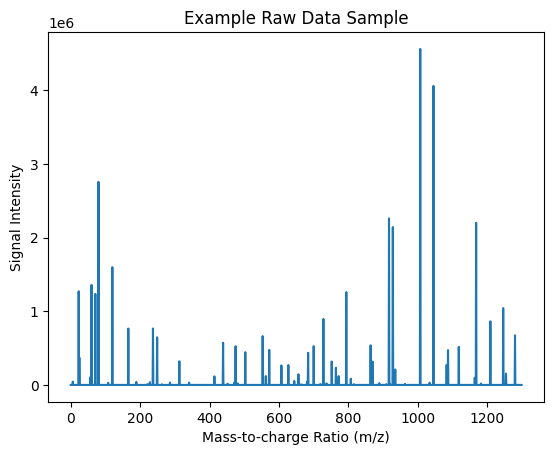

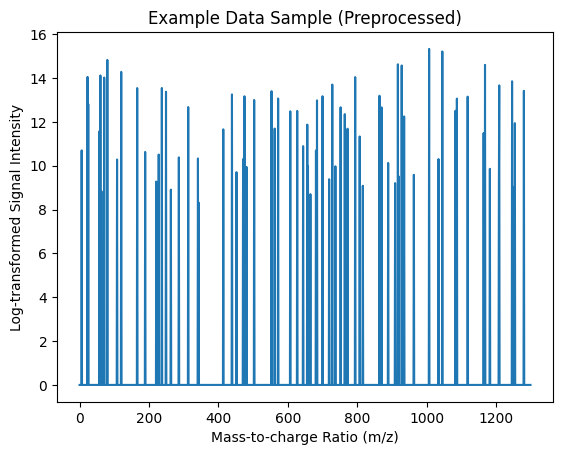

In [ ]:
# define helper functions for preprocessing and accessing data
def preprocess(x, y):
  x = tf.math.log1p(x)
  x = tf.expand_dims(x, axis=-1)
  return x, y

def getTrainValData():
  return tf.data.Dataset.from_tensor_slices((X_trainval, y_trainval)).map(preprocess,tf.data.AUTOTUNE).shuffle(buffer_size=64).batch(BATCH).prefetch(tf.data.AUTOTUNE)

def getTestData():
  return tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(preprocess,tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# output structure of each training batch
img, label = next(iter(getTrainValData()))
print(img.shape, label.shape)
print("range: " + str(tf.reduce_min(img)) + " - " + str(tf.reduce_max(img)))

# plot visualization of original training sample
plt.plot(df.iloc[0])
plt.title("Example Raw Data Sample")
plt.ylabel('Signal Intensity')
plt.xlabel('Mass-to-charge Ratio (m/z)')
plt.savefig("figures/original_data.png")
plt.show()

# plot visualization of preprocessed sample
plt.plot(preprocess(df.iloc[0], 0)[0])
plt.title("Example Data Sample (Preprocessed)")
plt.ylabel('Log-transformed Signal Intensity')
plt.xlabel('Mass-to-charge Ratio (m/z)')
plt.savefig("figures/preprocessed_data.png")
plt.show()

## **Set up Model Compliation and Fitting**
- Helper functions were created to compile and fit each model with the following specifications:
    - Adam optimization with 0.001 initial learning rate.
    - Categorical cross-entropy loss function.
    - Callback to restore parameters resulting in optimal validation loss after 20 epochs of no improvement.
        - The "compile_fit_model()" function returns the average validation accuracy of the model across 5 cross-validation folds.  

In [ ]:
# function for creating training callback to paramters with optimal validation loss after early stoppping
def create_callbacks():
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        verbose=1,
        restore_best_weights=True
    )

    return callback

# function for compiling and fitting model using Adam optimizer and categorical cross-entropy loss
def compile_fit_model(m = None, l = None, a = None, h = None, d = None):
    fold_no = 1
    k = 5
    kfold = KFold(n_splits=k, shuffle=True, random_state=SEED)
    scores = []

    # train the model once on each fold
    for train_index, val_index in kfold.split(X_trainval, y_trainval):

        # Split data into training and test sets for the current fold
        X_train_fold = X_trainval.iloc[train_index]
        y_train_fold = y_trainval[train_index]
        X_val_fold = X_trainval.iloc[val_index]
        y_val_fold = y_trainval[val_index]

        # preprocess and batch the separated training and validation folds
        train_fold = tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold)).map(preprocess,tf.data.AUTOTUNE).shuffle(buffer_size=64).batch(BATCH).prefetch(tf.data.AUTOTUNE)
        val_fold = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold)).map(preprocess,tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

        # a new model is created for each fold in order to avoid leakage
        if m == "ffn":
            model = build_ffn(l, a)
        elif m == "cnn":
            model = build_cnn(l, a)
        else:
            model = build_att(h, d, a)

        # Create and compile the model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=["accuracy"]
        )

        # Train the model
        hist = model.fit(
            train_fold,
            validation_data = val_fold,
            epochs = EPOCHS,
            callbacks = create_callbacks(),
            verbose = 0
        )

        # Evaluate the model
        scores.append(max(hist.history["val_accuracy"]))

        # clear previous training
        tf.keras.backend.clear_session()

        # delete the model
        del model

        # iterate to the next fold
        fold_no += 1

    # return the mean validation accuracy for the model
    return np.mean(scores)


## **Model Construction and Experimentation**
- A function was created to construct each type of model with different parameter values to specify architecture and activation functions. Refer to code comments for details of each model-building function.

### Model 1: Feed-Forward Neural Network
- The following function generates a standard feed-forward neural network architecture with a specificed activation function and customizable feed-forward layers that use batch normalization and random dropout. The model includes a softmax output for classification tasks.

In [ ]:
# function for building feed-forward neural network with dropout and adjustable activation function and layer architecture
def build_ffn(layers_arch, act_func):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_trainval.shape[1],))
    x = layers.BatchNormalization()(inputs)

    # create layer architecture (depth and width) specified in arguments
    for layer_size in layers_arch:
        x = layers.Dense(layer_size, activation=act_func, kernel_initializer=HE)(x)
        x = layers.Dropout(0.2)(x)
        x = layers.BatchNormalization()(x)

    # softmax output layer
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # Create model
    ffn = tf.keras.Model(inputs=inputs, outputs=outputs, name="FeedForwardNeuralNetwork")

    # return model object
    return ffn

### Model 2: 1-Dimensional Convolutional Neural Network
- The following function generates a convolutional neural network with specified convolutional architecture (# convolutional layers, kernel dimension, and number of filters) and activation function. The model produces a softmax output for classification tasks.

In [ ]:
# function for building convolutional neural network with variable layer architecture and activation function
def build_cnn(layers_arch, act_func):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_trainval.shape[1],1))
    x = layers.BatchNormalization()(inputs)

    # create layer architecture (# filters and kernel dimension) specified in arguments
    for layer in layers_arch:
        tmpx = x
        x = layers.Conv1D(layer[0], layer[1], activation=act_func, padding="same")(x)
        if tmpx.shape[-1] != layer[0]:
            tmpx = layers.Conv1D(layer[0], 1, padding="same")(tmpx)
        x = layers.Add()([x, tmpx])
        x = layers.MaxPooling1D(2)(x)

    # Flatten and Classify with feed-forward layer and softmax
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # store model
    cnn = tf.keras.Model(inputs, outputs, name = 'ConvolutionalNeuralNetwork')

    # return model object
    return cnn


### Model 3: Attention-Based Model
- The function below generates a classification model that uses multiheaded attention architecture. The inputs are embedded, attention is applied, and a feed-forward layer followed by softmax output is used for classification. The activation function, number of attention heads, and key dimension of each head are customizable via the function arguments.

In [ ]:
# function for building attention-based model with variable number of heads and key dimension
def build_att(num_heads=2, dim = 2, act_func="relu"):
    # input layer with batch normalization
    inputs = layers.Input(shape=(X_trainval.shape[1],1))
    x = layers.BatchNormalization()(inputs)

    # embed features
    x = layers.Dense((num_heads*dim), activation=act_func, kernel_initializer=HE)(x)
    x = layers.BatchNormalization()(x)

    # positional encoding
    positional_encoding = keras_hub.layers.SinePositionEncoding()(x)
    x = x + positional_encoding

    # store embedded inputs for residual connection
    shortcut = x

    # attention layer with specified number of heads and key dimension
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)

    # residual connection and batch normalization
    x = layers.Add()([x, shortcut])
    x = layers.BatchNormalization()(x)

    # dense layer with dropout and batch normalization
    x = layers.Dense(256, activation=act_func, kernel_initializer=HE)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)

    # flatten data and apply softmax activation layer
    x = layers.Flatten()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # store model
    att = tf.keras.Model(inputs, outputs, name = 'AttentionBasedNeuralNetwork')

    # return model object
    return att


## Setting up model comparative tests
- Each model was constructed and validated across a range of different architectures. The performance results of each set of parameters was added to a DataFrame for camparison purposes and plotted for visualzation.

In [ ]:
# construct ffns with different layer architectures. Format: [first layer width, second layer width, ..., last layer width]
ffn_layers = [[1024,128], [1024, 256], [256, 256], [1024, 256, 128]]

# construct ffns using relu and leaky relu activation
ffn_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

ffn_tests = []

# compile, train, and store model for each combination of architecture and activation function
for act_func in ffn_act_funcs:
    for layer_arch in ffn_layers:
        ffn_tests.append({
            "act_func": act_func,
            "layers": str(layer_arch),
            "val_accuracy": compile_fit_model('ffn', layer_arch, act_func)
        })
        gc.collect()

# store results in a dataframe for later reference
ffn_df = pd.DataFrame(ffn_tests)

ffn_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 15.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 14.
Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 19.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 10.
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 11.
Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 19.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 23.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 13.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 12.
Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 25.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 15.
Epoch 35: early stopping
Restoring model weights from the end of 

,act_func,layers,val_accuracy
0,relu,"[1024, 128]",0.941880
1,relu,"[1024, 256]",0.950427
2,relu,"[256, 256]",0.931624
3,relu,"[1024, 256, 128]",0.940171
4,"<LeakyReLU name=leaky_re_lu, built=True>","[1024, 128]",0.947009
5,"<LeakyReLU name=leaky_re_lu, built=True>","[1024, 256]",0.938462
6,"<LeakyReLU name=leaky_re_lu, built=True>","[256, 256]",0.928205
7,"<LeakyReLU name=leaky_re_lu, built=True>","[1024, 256, 128]",0.941880


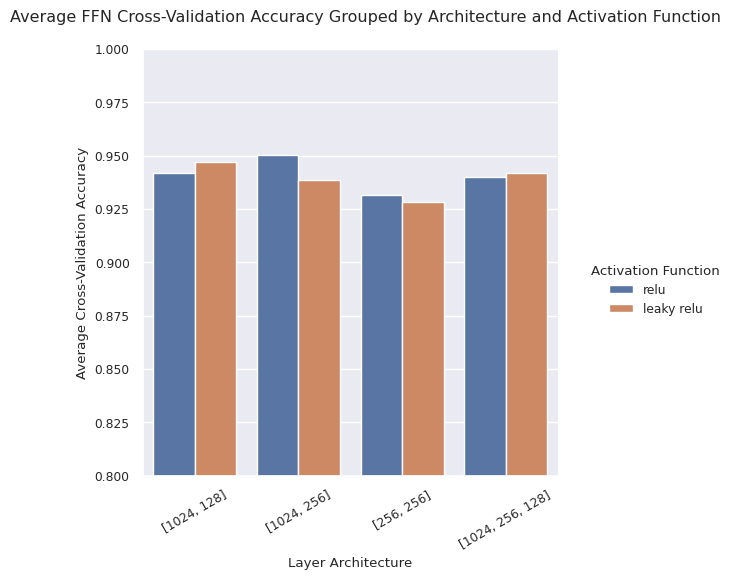

In [ ]:
# create copy of results df and change activation function to more understandable value
ffn_df_p = ffn_df.copy(deep=True)
ffn_df_p.loc[ffn_df_p['act_func'] != 'relu', 'act_func'] = 'leaky relu'

# plot FFN cross-validation results
sns.set_theme(font_scale=0.8)
p = sns.catplot(
    x="layers",
    y="val_accuracy",
    hue="act_func",
    data=ffn_df_p,
    kind="bar",
)

# plot customization
p.set(ylim=(0.8, 1))
p.set_axis_labels("Layer Architecture", "Average Cross-Validation Accuracy")
p.fig.suptitle("Average FFN Cross-Validation Accuracy Grouped by Architecture and Activation Function", y=1.05)
p.legend.set_title("Activation Function")
p.set_xticklabels(rotation=30, horizontalalignment='center')

p.savefig("figures/ffn_results.png", bbox_inches='tight')
plt.show()

In [ ]:
# construct cnns with different layer architectures. Each nested bracket pair is a layer: [# filters, kernel dimension]
cnn_layers = [
    [[32,32], [32, 64]],
    [[32,16], [32, 64]],
    [[32,32], [64, 32]],
    [[32,16], [64, 32]]
]

# construct cnns using relu and leaky relu activation
cnn_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

cnn_tests = []

# compile, train, and store model for each combination of architecture and activation function
for act_func in cnn_act_funcs:
    for layer_arch in cnn_layers:
        cnn_tests.append({
            "act_func": act_func,
            "layers": str(layer_arch),
            "val_accuracy": compile_fit_model('cnn', layer_arch, act_func)
        })
        gc.collect()

# store results in a dataframe for later reference
cnn_df = pd.DataFrame(cnn_tests)

cnn_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 11.
Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 25.
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 30.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 8.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 14.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 19.
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 20.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 14.
Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 24.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 40: early stopping
Restoring model weights from the end of the

,act_func,layers,val_accuracy
0,relu,"[[32, 32], [32, 64]]",0.924786
1,relu,"[[32, 16], [32, 64]]",0.935043
2,relu,"[[32, 32], [64, 32]]",0.926496
3,relu,"[[32, 16], [64, 32]]",0.931624
4,"<LeakyReLU name=leaky_re_lu, built=True>","[[32, 32], [32, 64]]",0.941880
5,"<LeakyReLU name=leaky_re_lu, built=True>","[[32, 16], [32, 64]]",0.933333
6,"<LeakyReLU name=leaky_re_lu, built=True>","[[32, 32], [64, 32]]",0.928205
7,"<LeakyReLU name=leaky_re_lu, built=True>","[[32, 16], [64, 32]]",0.933333


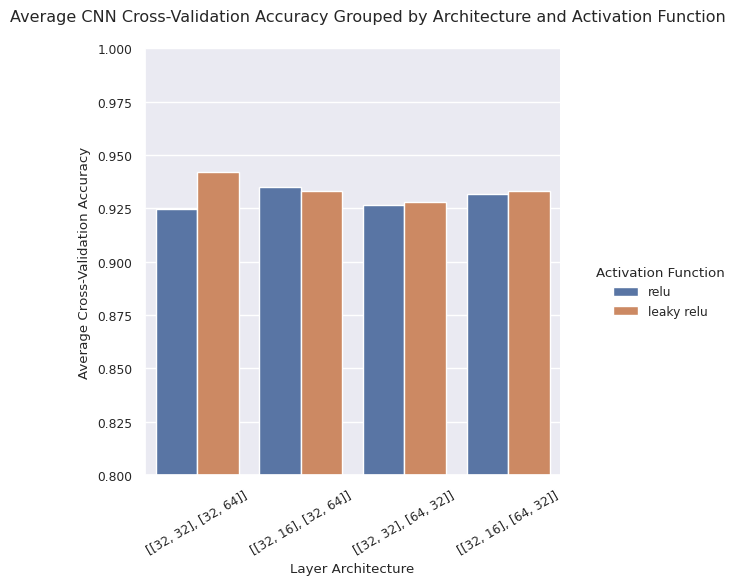

In [ ]:
# create copy of results dataframe and change activation function to more understandable value
cnn_df_p = cnn_df.copy(deep=True)
cnn_df_p.loc[cnn_df_p['act_func'] != 'relu', 'act_func'] = 'leaky relu'

# plot CNN cross-validation results
sns.set_theme(font_scale=0.8)
p = sns.catplot(
    x="layers",
    y="val_accuracy",
    hue="act_func",
    data=cnn_df_p,
    kind="bar",
)

# plot customization
p.set(ylim=(0.8, 1))
p.set_axis_labels("Layer Architecture", "Average Cross-Validation Accuracy")
p.fig.suptitle("Average CNN Cross-Validation Accuracy Grouped by Architecture and Activation Function", y=1.05)
p.legend.set_title("Activation Function")
p.set_xticklabels(rotation=30, horizontalalignment='center')

p.savefig("figures/cnn_results.png", bbox_inches='tight')
plt.show()

In [ ]:
# construct attention models with different key dimensions
att_dims = [8,16]

# construct attention models with different numbers of heads
att_num_heads = [8,16]

# construct atttention models with relu and leaky relu activation
att_act_funcs = ["relu", layers.LeakyReLU(alpha=0.2)]

att_tests = []

# compile, train, and store model for each combination of key dimension, number of heads, and activation function
for num_head in att_num_heads:
    for act_func in att_act_funcs:
        for dim in att_dims:
            att_tests.append({
                    "act_func": act_func,
                    "arch": str([num_head, dim]),
                    "val_accuracy": compile_fit_model('att', a = act_func, h = num_head, d = dim)
                })
            gc.collect()

# store results in a dataframe for later reference
att_df = pd.DataFrame(att_tests)

att_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 14.
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 11.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 8.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 10.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 10.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 15.
Epoch 32: early stopping
Restoring model weights from the end of the be

,act_func,arch,val_accuracy
0,relu,"[8, 8]",0.911111
1,relu,"[8, 16]",0.895727
2,"<LeakyReLU name=leaky_re_lu, built=True>","[8, 8]",0.912821
3,"<LeakyReLU name=leaky_re_lu, built=True>","[8, 16]",0.924786
4,relu,"[16, 8]",0.914530
5,relu,"[16, 16]",0.899145
6,"<LeakyReLU name=leaky_re_lu, built=True>","[16, 8]",0.914530
7,"<LeakyReLU name=leaky_re_lu, built=True>","[16, 16]",0.914530


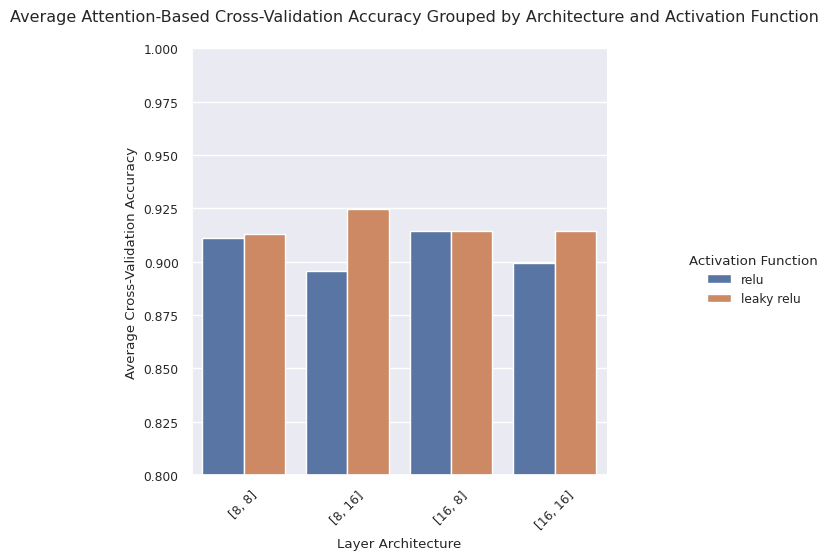

In [ ]:
# create copy of results df and change activation function to more understandable value
att_df_p = att_df.copy(deep=True)
att_df_p.loc[att_df_p['act_func'] != 'relu', 'act_func'] = 'leaky relu'

# plot attention-based cross-validation results
sns.set_theme(font_scale=0.8)
p = sns.catplot(
    x="arch",
    y="val_accuracy",
    hue="act_func",
    data=att_df_p,
    kind="bar",
)

# plot customization
p.set(ylim=(0.8, 1))
p.set_axis_labels("Layer Architecture", "Average Cross-Validation Accuracy")
p.fig.suptitle("Average Attention-Based Cross-Validation Accuracy Grouped by Architecture and Activation Function", y=1.05)
p.legend.set_title("Activation Function")
p.set_xticklabels(rotation=45, horizontalalignment='center')

p.savefig("figures/att_results.png", bbox_inches='tight')
plt.show()

## Model Evaluation
- The training functions were reworked to train the final model on the combined training and validation data, then the model with the highest validation accuracy was identified, trained on the combined data, and evaluated on the test data.

In [ ]:
# function for creating callback to paramters with optimal training loss after early stopping
def create_callbacks_test():
    callback = tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=20,
        verbose=1,
        restore_best_weights=True
    )

# function for compiling and fitting optimal model on training + validation data
def compile_fit_model_test(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    hist = model.fit(
        getTrainValData(),
        epochs = EPOCHS,
        callbacks = create_callbacks_test(),
        verbose = 0
    )

    return model.evaluate(getTestData())



In [ ]:
# identify best model parameters from each type of model
best_ffn = ffn_df.sort_values(by = "val_accuracy", ascending = False).iloc[0]
best_cnn = cnn_df.sort_values(by = "val_accuracy", ascending = False).iloc[0]
best_att = att_df.sort_values(by = "val_accuracy", ascending = False).iloc[0]

# create new models with the same parameters as the best models
ffn = build_ffn(ast.literal_eval(best_ffn['layers']), best_ffn['act_func'])
cnn = build_cnn(ast.literal_eval(best_cnn['layers']), best_cnn['act_func'])
att = build_att(ast.literal_eval(best_att['arch'])[0], ast.literal_eval(best_att['arch'])[0], best_att['act_func'])

# store new models and validation performance metrics in a dataframe
best_models_df = pd.DataFrame({'model': [ffn, cnn, att],
                               'model_name': [ffn.name, cnn.name, att.name],
                               'val_accuracy': [best_ffn['val_accuracy'], best_cnn['val_accuracy'], best_att['val_accuracy']]})

# identify which of the three models has the greatest validation accuracy
best_models_df = best_models_df.sort_values(by = "val_accuracy", ascending = False)
print(best_models_df)

# retrain the best model on combined training + validation data and output test set performance
best_model = (best_models_df.iloc[0])['model']
loss, acc = compile_fit_model_test(best_model)
print(f"The optimal model achieved {acc:.3f} test accuracy and {loss:.3f} test loss.")

                                               model  \
0  <Functional name=FeedForwardNeuralNetwork, bui...   
1  <Functional name=ConvolutionalNeuralNetwork, b...   
2  <Functional name=AttentionBasedNeuralNetwork, ...   

                    model_name  val_accuracy  
0     FeedForwardNeuralNetwork      0.950427  
1   ConvolutionalNeuralNetwork      0.941880  
2  AttentionBasedNeuralNetwork      0.924786  
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.9242 - loss: 0.1949
The optimal model achieved 0.924 test accuracy and 0.195 test loss.


### Plot of Accuracy Per Class
- A plot of the model accuracy for each outcome class is generated below, to be used for understanding the relationship between accuracy and class representation in training data.

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step


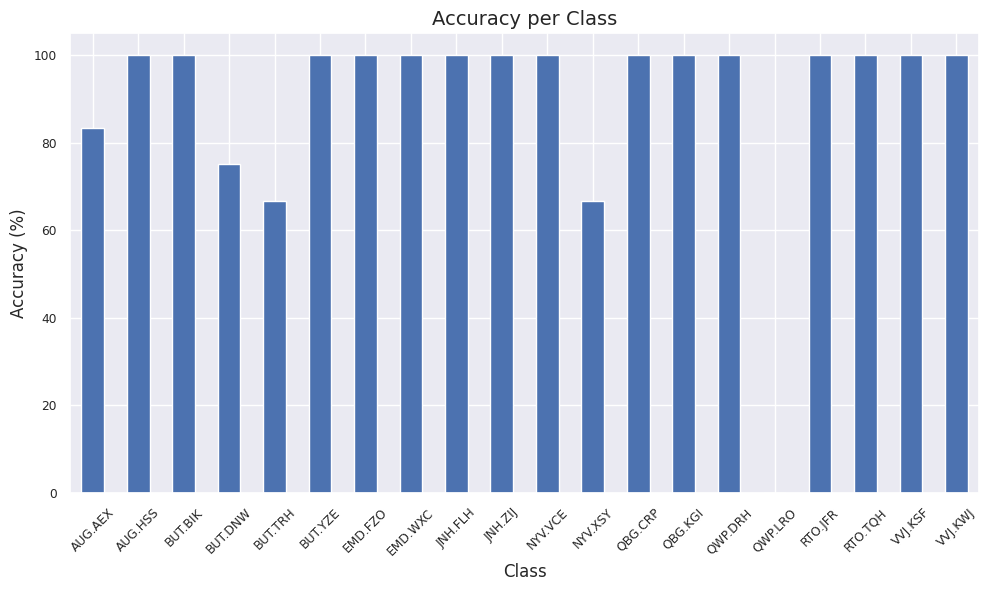

In [ ]:
# get test data for predictions
test_data = getTestData()

# Get the predicted classes
predicted_probabilities = best_model.predict(test_data)
pred_indices = np.argmax(predicted_probabilities, axis=1)

# Map indices back to labels
categories = ohe.categories_[0]
y_pred = [categories[i] for i in pred_indices]

# Extract the true classes from the tf.data.Dataset
y_true = np.concatenate([ohe.inverse_transform(y) for x, y in test_data], axis=0).ravel()

# Put true and predicted classes side-by-side in a DataFrame
results = pd.DataFrame({
    "True Class": y_true,
    "Predicted Class": y_pred
})

# get the total count of test samples per class
total_count = results.groupby("True Class")["True Class"].count()

# get the total number of true predictions per class
true_count = results[results["True Class"] == results['Predicted Class']].groupby("True Class")["True Class"].count()

# use the above values to calculate accuracy per class
class_accuracy = (true_count / total_count).fillna(0) * 100

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
class_accuracy.plot(kind='bar', ax=ax)

# Add labels and title
ax.set_title('Accuracy per Class', fontsize=14)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)

# Set y-axis limit to 0-105 to give a little headroom above 100%
ax.set_ylim(0, 105)

# Keep x-axis labels horizontal and readable
plt.xticks(rotation=45)

# save figure as png and display figure in notebook
plt.tight_layout()
plt.savefig("figures/test_accuracy_class.png", bbox_inches='tight')
plt.show()

### **Conclusion and Future Directions**
- Strong average cross-validation accuracy was observed, with most models achieving accuracies within the range of 0.88-0.95
- Models using leaky relu generally outperformed standard relu, although both activation functions often performed similalry for the same model architectures.
- The feed-forward network with two hidden layers (widths: 1024, 256) and relu activation performed the best during cross-validation and achieved a test accuracy of 0.924.
- The optimal performance of the feed-forward model and relatively poor performance of the attention model and CNN suggests that increased model complexity does not improve accuracy for small mass spectromtery datasets such as Micromass.
- Failure to outperform simpler linear models from previous literature demonstrates that complex deep-learning models require equally complex and large datasets. Future attempts to outperform Micromass benchmarks should focus on simpler traditional machine learning approaches such as boosted tree classifiers.